# Multi-Country ECH GREASE Analysis
This report provides a comprehensive, data-driven analysis of network behavior when ECH GREASE is enabled across global ISP networks. The objective is to identify potential network interference, assess deployment readiness, and provide detailed diagnostic data for network engineers.

> **How to (re-)run this notebook:**
> 
> 1. Ensure you have Python installed and activate your virtual environment (e.g., `source ../../.venv/bin/activate`).
> 2. Install the required libraries if you haven't already: `pip install pandas numpy matplotlib seaborn ipywidgets jupyter`.
> 3. Open this file in Jupyter Notebook (`jupyter notebook report.ipynb`) or an IDE (like VS Code), and execute the cells sequentially.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML

# Configure visualization settings
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Configuration
DOMAIN = "cloudflare-ech_com" # Or "www_google_com"
DATA_DIR = f"{DOMAIN}/"
RESULTS_FILE = f"{DATA_DIR}results.csv"

print(f"Dataset initialized for domain: {DOMAIN}\nInput File: {RESULTS_FILE}")


Dataset initialized for domain: cloudflare-ech_com
Input File: cloudflare-ech_com/results.csv


## 1. Data Ingestion and Proxy Quality Assessment
Initial loading of the dataset. We also evaluate the SOAX proxy integrity and establish a reliable baseline by validating the vantage points (using GeoDB AS/IP matching) exclusively on the control group where ECH GREASE is disabled (OFF).


,Count
Total Raw Requests,1622
GeoDB Matched Requests (Target for Analysis),1107
Unique Countries Tested,203
Unique ISPs Tested,756


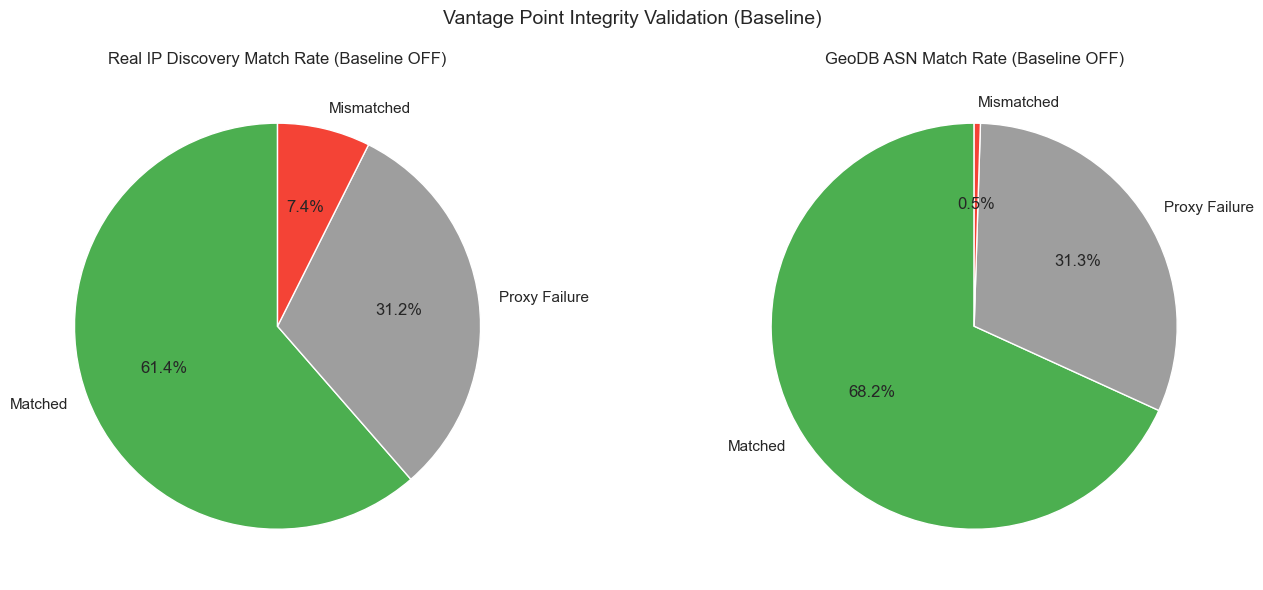

In [2]:
# Load dataset
try:
    df = pd.read_csv(RESULTS_FILE)
except FileNotFoundError:
    print(f"Error: Dataset {RESULTS_FILE} not found.")
    df = pd.DataFrame()

if not df.empty:
    # Map true/false to categories and handle nulls representing proxy/connection failures
    df['ip_match_label'] = df['ip_match'].map({True: 'Matched', False: 'Mismatched'}).fillna('Proxy Failure')
    df['asn_match_label'] = df['asn_match'].map({True: 'Matched', False: 'Mismatched'}).fillna('Proxy Failure')

    # Keep original boolean for filtering where needed, but fill NAs as False just for those specific checks
    df['ip_match'] = df['ip_match'].fillna(False).astype(bool)
    df['asn_match'] = df['asn_match'].fillna(False).astype(bool)

    # We do not filter out failed requests here (e.g., by missing exit_node_ip) 
    # because an ECH ON request might fail to connect entirely due to interference.
    # Instead, we focus our analysis on vantage points that are verified via GeoDB 
    # during their baseline (ECH OFF) test.
    df_valid = df.copy()
    df_off = df_valid[df_valid["ech_grease"] == False]
    
    total_requests = len(df)
    geodb_matched_requests = len(df[df['asn_match'] == True])
    unique_countries = df['country_name'].nunique()
    unique_isps = df['isp'].nunique()

    summary_data = {
        "Metric": ["Total Raw Requests", "GeoDB Matched Requests (Target for Analysis)", "Unique Countries Tested", "Unique ISPs Tested"],
        "Count": [total_requests, geodb_matched_requests, unique_countries, unique_isps]
    }
    summary_df = pd.DataFrame(summary_data).set_index("Metric")
    # Display table cleanly without index to avoid two-line headers
    summary_df.index.name = None
    display(summary_df)

    # Data Quality: Proxy Integrity (Baseline OFF Requests)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    color_map = {'Matched': '#4CAF50', 'Mismatched': '#F44336', 'Proxy Failure': '#9E9E9E'}

    ip_match_counts = df_off['ip_match_label'].value_counts()
    axes[0].pie(ip_match_counts, labels=ip_match_counts.index, autopct="%1.1f%%", startangle=90, colors=[color_map.get(x, '#333333') for x in ip_match_counts.index])
    axes[0].set_title("Real IP Discovery Match Rate (Baseline OFF)")

    asn_match_counts = df_off['asn_match_label'].value_counts()
    axes[1].pie(asn_match_counts, labels=asn_match_counts.index, autopct="%1.1f%%", startangle=90, colors=[color_map.get(x, '#333333') for x in asn_match_counts.index])
    axes[1].set_title("GeoDB ASN Match Rate (Baseline OFF)")

    plt.suptitle("Vantage Point Integrity Validation (Baseline)", fontsize=14)
    plt.tight_layout()
    plt.show()


## 2. Global Connectivity Distribution
A simplistic "success rate" can mask underlying issues by grouping disparate failure modes. Here, we present the exact distribution of HTTP status codes and `curl` exit codes across all valid proxy connections, comparing ECH GREASE OFF vs. ON. This provides a high-resolution view of how the network state transitions when GREASE is introduced.


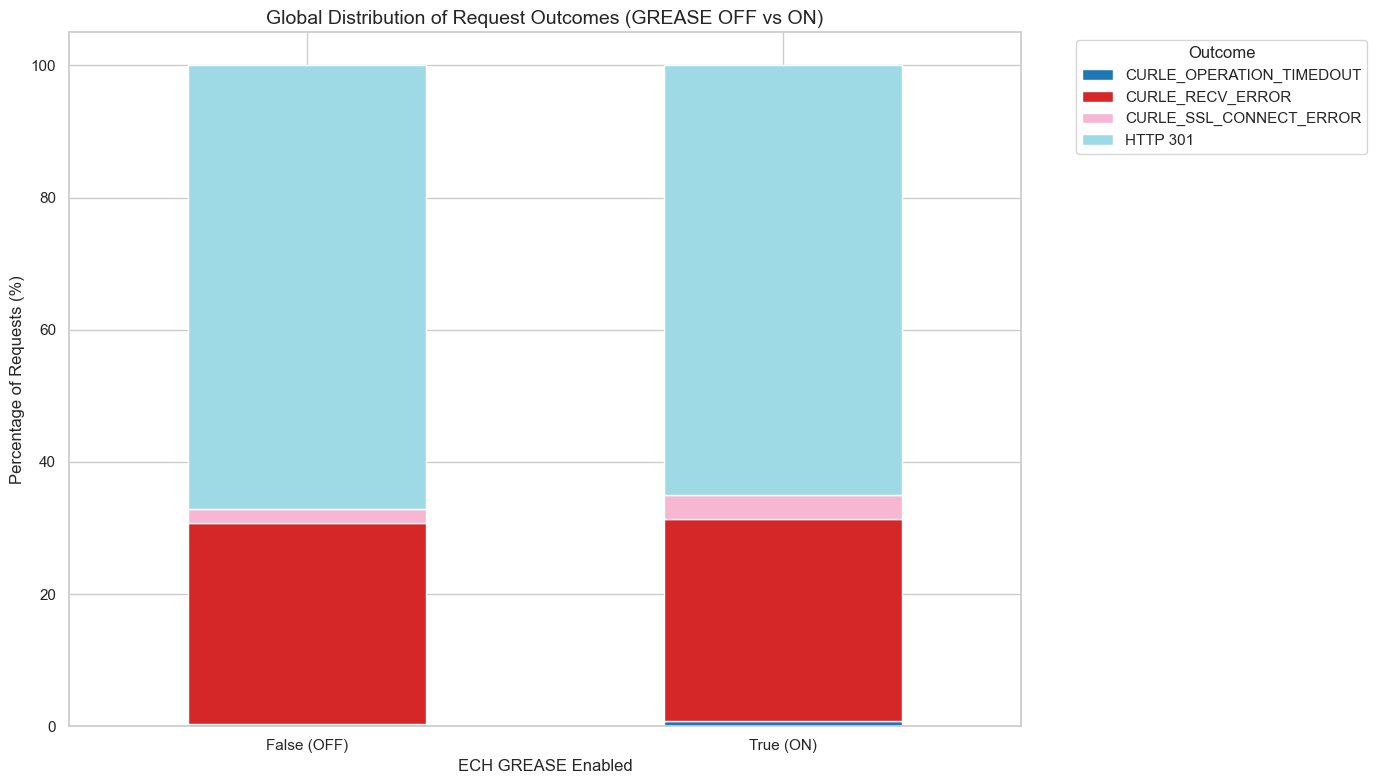

In [3]:
if not df_valid.empty:
    # Categorize outcome
    def categorize_outcome(row):
        if row['http_status'] >= 200 and row['http_status'] < 400:
            return f"HTTP {int(row['http_status'])}"
        elif row['http_status'] >= 400:
            return f"HTTP Error {int(row['http_status'])}"
        else:
            return row['curl_error_name'] if pd.notna(row['curl_error_name']) else "Unknown Error"

    df_valid['outcome'] = df_valid.apply(categorize_outcome, axis=1)

    # Pivot for visualization
    outcome_dist = df_valid.groupby(['ech_grease', 'outcome']).size().unstack(fill_value=0)
    
    # Normalize to percentages
    outcome_pct = outcome_dist.div(outcome_dist.sum(axis=1), axis=0) * 100

    # Plot
    ax = outcome_pct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
    plt.title("Global Distribution of Request Outcomes (GREASE OFF vs ON)", fontsize=14)
    plt.xlabel("ECH GREASE Enabled")
    plt.ylabel("Percentage of Requests (%)")
    plt.xticks(ticks=[0, 1], labels=["False (OFF)", "True (ON)"], rotation=0)
    plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 3. Country-Level Connectivity and Interference Analysis
We pair the GREASE OFF and GREASE ON requests for each specific ISP within each country to measure deterministic degradation. 
We define a connection as 'successful' if it returns an HTTP status between 200 and 399. 
We classify ISPs into the following states based on their paired tests:
*   **Parity (Success):** Both OFF and ON succeeded.
*   **Parity (Consistent Failure):** Both OFF and ON failed with the same error (neutral impact).
*   **Degraded (Interference):** OFF succeeded, but ON failed. This is the primary indicator of ECH blocking.
*   **Improved:** OFF failed, but ON succeeded (rare, usually anomalous).
*   **Broken Proxy (Inconclusive):** Both failed, but with different network errors.


state,Degraded (Interference),Parity (Consistent Failure),Parity (Success),Improved,Broken Proxy (Inconclusive),Total ISPs Tested,Interference Rate (%)
country_name,,,,,,,
Russian Federation,15,11,1,0,0,27,55.555556
Burkina Faso,1,2,0,0,0,3,33.333333
Ukraine,1,0,3,0,0,4,25.000000
Afghanistan,1,4,2,0,0,7,14.285714
United States,0,11,7,0,0,18,0.000000
Iraq,0,4,10,0,0,14,0.000000
United Kingdom,0,6,7,0,0,13,0.000000
Brazil,0,5,7,0,0,12,0.000000
Kazakhstan,0,2,10,0,0,12,0.000000


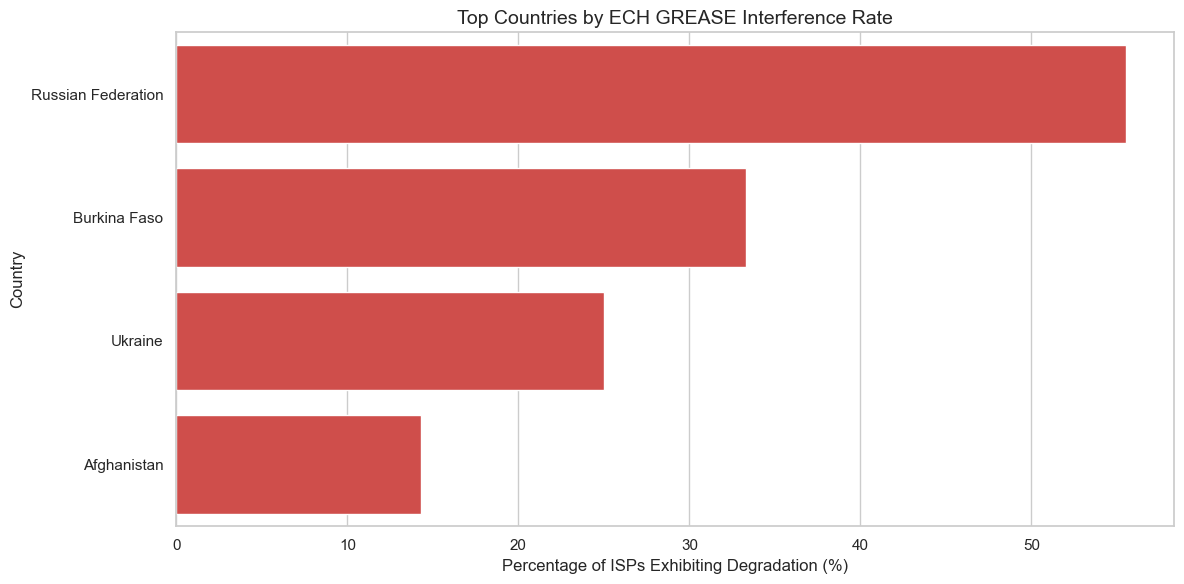

In [4]:
if not df_valid.empty:
    # Pair the data
    df_on = df_valid[df_valid["ech_grease"] == True].set_index(["country_code", "country_name", "isp"])
    df_off = df_valid[df_valid["ech_grease"] == False].set_index(["country_code", "country_name", "isp"])
    paired_df = df_off.join(df_on, lsuffix="_off", rsuffix="_on", how="inner")
    
    # Define success strictly as receiving a valid HTTP response
    paired_df["success_off"] = (paired_df["http_status_off"] >= 200) & (paired_df["http_status_off"] < 400)
    paired_df["success_on"] = (paired_df["http_status_on"] >= 200) & (paired_df["http_status_on"] < 400)

    # Classify the delta
    def classify_delta(row):
        if row["success_off"] and not row["success_on"]:
            return "Degraded (Interference)"
        elif not row["success_off"] and row["success_on"]:
            return "Improved"
        elif row["success_off"] and row["success_on"]:
            return "Parity (Success)"
        else:
            if row["curl_error_name_off"] == row["curl_error_name_on"]:
                return "Parity (Consistent Failure)"
            else:
                return "Broken Proxy (Inconclusive)"

    paired_df["state"] = paired_df.apply(classify_delta, axis=1)

    # Aggregate by Country
    country_summary = paired_df.groupby("country_name")["state"].value_counts().unstack(fill_value=0)
    
    # Ensure columns exist
    for col in ["Degraded (Interference)", "Parity (Success)", "Parity (Consistent Failure)", "Improved", "Broken Proxy (Inconclusive)"]:
        if col not in country_summary.columns:
            country_summary[col] = 0
            
    country_summary["Total ISPs Tested"] = country_summary.sum(axis=1)
    country_summary["Interference Rate (%)"] = (country_summary["Degraded (Interference)"] / country_summary["Total ISPs Tested"]) * 100
    
    # Sort by Interference Rate and then Total ISPs
    country_summary = country_summary.sort_values(by=["Interference Rate (%)", "Total ISPs Tested"], ascending=[False, False])
    
    display(HTML("<h3>Country-Level State Distribution</h3>"))
    # Use a scrollable div to display the full table without cluttering the notebook
    scrollable_table = f'<div style="max-height: 400px; overflow-y: auto;">{country_summary.to_html(classes="dataframe")}</div>'
    display(HTML(scrollable_table))

    # Visualize Top 20 Countries by Interference Rate (where at least 1 interference occurred)
    interfered_countries = country_summary[country_summary["Interference Rate (%)"] > 0].head(20)
    
    if not interfered_countries.empty:
        plt.figure(figsize=(12, max(6, len(interfered_countries)*0.4)))
        sns.barplot(data=interfered_countries.reset_index(), y="country_name", x="Interference Rate (%)", color="#E53935")
        plt.title("Top Countries by ECH GREASE Interference Rate", fontsize=14)
        plt.xlabel("Percentage of ISPs Exhibiting Degradation (%)")
        plt.ylabel("Country")
        plt.tight_layout()
        plt.show()
    else:
        print("No definitive interference detected in the paired dataset.")


## 4. Interference Error Anatomy
For the subset of connections classified as **Degraded (Interference)**, we analyze the specific network errors generated by `curl` when GREASE is enabled.
Understanding whether the failure is a TCP Reset (`CURLE_RECV_ERROR`), a Timeout (`CURLE_OPERATION_TIMEDOUT`), or an SSL Handshake failure (`CURLE_SSL_CONNECT_ERROR`) provides critical diagnostic signals to network engineers regarding the behavior of the interfering middleboxes.


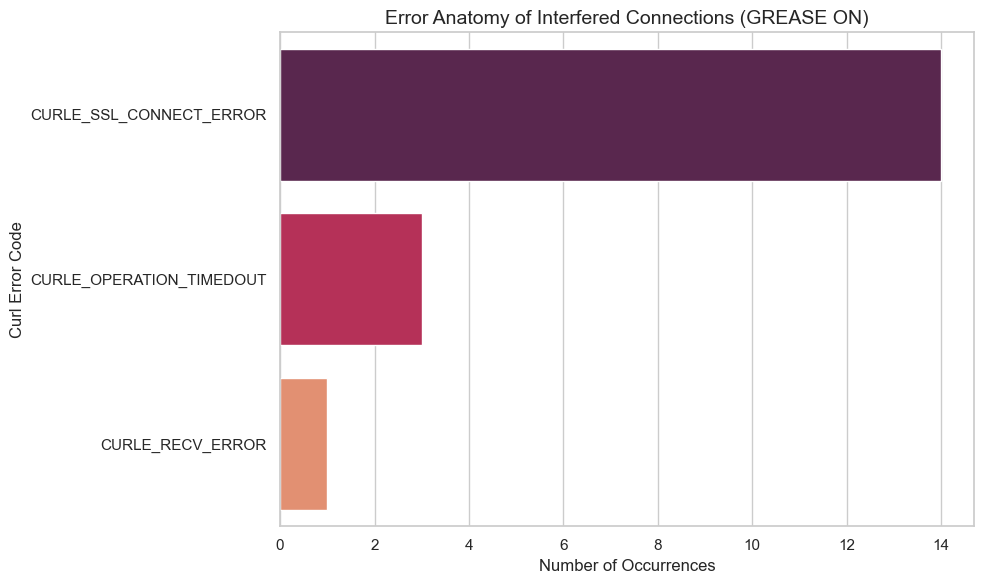

curl_error_name_on,CURLE_OPERATION_TIMEDOUT,CURLE_RECV_ERROR,CURLE_SSL_CONNECT_ERROR
country_name,,,
Afghanistan,0,0,1
Burkina Faso,0,1,0
Russian Federation,3,0,12
Ukraine,0,0,1


In [5]:
if not df_valid.empty and "state" in paired_df.columns:
    degraded_df = paired_df[paired_df["state"] == "Degraded (Interference)"]
    
    if not degraded_df.empty:
        error_counts = degraded_df["curl_error_name_on"].value_counts()
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=error_counts.values, y=error_counts.index, hue=error_counts.index, palette="rocket", legend=False)
        plt.title("Error Anatomy of Interfered Connections (GREASE ON)", fontsize=14)
        plt.xlabel("Number of Occurrences")
        plt.ylabel("Curl Error Code")
        plt.tight_layout()
        plt.show()
        
        display(HTML("<h3>Detailed Breakdown of Interference Errors by Country</h3>"))
        error_detail = degraded_df.groupby(["country_name", "curl_error_name_on"]).size().unstack(fill_value=0)
        display(error_detail)
    else:
        print("No interference data available for error anatomy analysis.")


## 5. Interactive Data Explorer
Use the controls below to drill down into the raw data for specific countries or individual Connection States. This tool exposes the raw metrics, ASNs, and HTTP/Curl statuses, enabling detailed, row-level inspection of all vantage points.


In [6]:
if not df_valid.empty and "state" in paired_df.columns:
    # Prepare data for display
    display_df = paired_df.reset_index().copy()
    display_df = display_df.rename(columns={
        "country_name": "Country",
        "isp": "ISP",
        "state": "Connection State",
        "geodb_asn_on": "GeoDB ASN",
        "geodb_as_name_on": "GeoDB AS Name",
        "discovered_ip_on": "Discovered IP",
        "http_status_off": "HTTP (OFF)",
        "http_status_on": "HTTP (ON)",
        "curl_error_name_off": "Error (OFF)",
        "curl_error_name_on": "Error (ON)",
        "tls_handshake_ms_off": "TLS ms (OFF)",
        "tls_handshake_ms_on": "TLS ms (ON)"
    })
    
    cols_to_show = ["Country", "ISP", "Connection State", "GeoDB ASN", "GeoDB AS Name", "Discovered IP", 
                    "HTTP (OFF)", "HTTP (ON)", "Error (OFF)", "Error (ON)", "TLS ms (OFF)", "TLS ms (ON)"]
    display_df = display_df[cols_to_show]
    display_df['GeoDB ASN'] = display_df['GeoDB ASN'].astype('Int64')

    # Widgets
    country_dropdown = widgets.Dropdown(
        options=['All'] + sorted(display_df['Country'].unique().tolist()),
        value='All',
        description='Country:',
        disabled=False,
    )
    
    state_dropdown = widgets.Dropdown(
        options=['All'] + sorted(display_df['Connection State'].unique().tolist()),
        value='All',
        description='State:',
        disabled=False,
    )

    def filter_data(country, state):
        filtered = display_df
        if country != 'All':
            filtered = filtered[filtered['Country'] == country]
        if state != 'All':
            filtered = filtered[filtered['Connection State'] == state]
        
        print(f"Showing {len(filtered)} records")
        scrollable_table = f'<div style="max-height: 500px; overflow-y: auto;">{filtered.to_html(classes="dataframe", max_rows=None)}</div>'
        return HTML(scrollable_table)

    widgets.interact(filter_data, country=country_dropdown, state=state_dropdown);
else:
    print("Data not available for interactive explorer.")


interactive(children=(Dropdown(description='Country:', options=('All', 'Afghanistan', 'Albania', 'Algeria', 'A…